# R2R — Exploratory Data Analysis

**Dataset:** `data/features/training_dataset.csv`

**Goal:** understand feature distributions, correlations with the target
(`correct`), cold-start NaN impact, and how empirical recall compares to
the FSRS theoretical retrievability before model training .

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering.feature_manifest import (
    ALL_FEATURES, NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
    BOOLEAN_FEATURES, TARGET,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

DATA_PATH = "../data/features/training_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.head(3)

shape: (266620, 57)


,id,user_id,question_id,session_id,review_time,previous_review_time,correct,confidence,response_time_seconds,hesitation_seconds,answer_changes,repetition_number,id_question,user_id_question,subject,topic,question_difficulty,word_count,character_count,created_at,id_session,user_id_session,started_at,ended_at,id_attempt,question_position,confidence_score,difficulty,question_position_in_session,total_revisions,last_review_correct,last_review_confidence_score,last_review_response_time,last_review_hesitation,success_rate,average_confidence,average_response_time,average_hesitation,review_interval_days,hour_of_day,day_of_week,session_duration_minutes,days_since_last_session,fsrs_recall_probability,had_fsrs_estimate,user_success_rate,user_average_confidence,user_average_response_time,question_global_success_rate,recent_success_rate_5,recent_confidence_5,consecutive_correct,hesitation_response_ratio,normalized_interval_days,normalized_repetition_number,normalized_avg_response_time,normalized_avg_hesitation
0,575547cb-1796-4fb1-9418-cbcd25447851,00a52a8c-7daf-4864-8bdb-5ac234fcd546,a37f6023-4ac0-48f4-b34c-b4f3c3e860fb,dc1d90d3-efe3-4753-832b-af10a10c0b33,2026-04-23 23:35:00.000000,NaN,True,HIGH,47.27,9.92,0,0,a37f6023-4ac0-48f4-b34c-b4f3c3e860fb,00a52a8c-7daf-4864-8bdb-5ac234fcd546,Physics,Electromagnetism,MEDIUM,72,394,2026-04-10 13:00:00,dc1d90d3-efe3-4753-832b-af10a10c0b33,00a52a8c-7daf-4864-8bdb-5ac234fcd546,2026-04-23 23:35:00,2026-04-23 23:39:13.879852,52412e6d-ab50-48ea-9c99-ce3ef4cd8f64,1,0.9,2,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,3,4.231331,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,4f523cc8-edf0-470c-bc95-6f01844d9c5d,00a52a8c-7daf-4864-8bdb-5ac234fcd546,d2caffd3-f0af-4ec3-8d24-2f90c00d8dad,dc1d90d3-efe3-4753-832b-af10a10c0b33,2026-04-23 23:35:56.584644,NaN,True,HIGH,44.60,12.73,0,0,d2caffd3-f0af-4ec3-8d24-2f90c00d8dad,00a52a8c-7daf-4864-8bdb-5ac234fcd546,Computer Science,Algorithms,MEDIUM,53,346,2026-04-23 13:00:00,dc1d90d3-efe3-4753-832b-af10a10c0b33,00a52a8c-7daf-4864-8bdb-5ac234fcd546,2026-04-23 23:35:00,2026-04-23 23:39:13.879852,39364a90-eb98-4f14-bd91-e17769ce7fec,2,0.9,2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,3,4.231331,0.0,NaN,0,1.0,0.9,47.270,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,cf0c79cd-e36b-4e07-9b2e-625adf062436,00a52a8c-7daf-4864-8bdb-5ac234fcd546,f937dd43-64eb-4c76-993e-b1b5a6e4d7b8,dc1d90d3-efe3-4753-832b-af10a10c0b33,2026-04-23 23:36:50.470175,NaN,True,HIGH,54.12,15.42,0,0,f937dd43-64eb-4c76-993e-b1b5a6e4d7b8,00a52a8c-7daf-4864-8bdb-5ac234fcd546,Chemistry,Inorganic Chemistry,EASY,29,159,2026-04-22 13:00:00,dc1d90d3-efe3-4753-832b-af10a10c0b33,00a52a8c-7daf-4864-8bdb-5ac234fcd546,2026-04-23 23:35:00,2026-04-23 23:39:13.879852,e6190fbf-fc36-4be2-999a-49d8703aec47,3,0.9,1,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,3,4.231331,0.0,NaN,0,1.0,0.9,45.935,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


## 1. Target balance

correct
True     0.5177
False    0.4823
Name: proportion, dtype: float64

Majority-class baseline accuracy: 0.5177


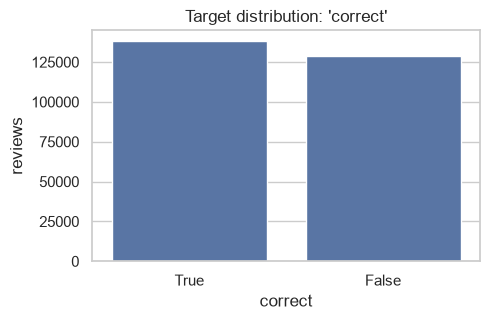

In [2]:
target_counts = df[TARGET].value_counts()
target_ratio = df[TARGET].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax)
ax.set_title("Target distribution: 'correct'")
ax.set_ylabel("reviews")

print(target_ratio.round(4))
majority = target_ratio.max()
print(f"\nMajority-class baseline accuracy: {majority:.4f}")

**Observation:** classes are close to balanced (~53/47), so no resampling
is needed and accuracy is a usable (if weak) metric; ROC-AUC remains the
primary comparison metric.

## 2. Missing values (cold start)

rows with total_revisions == 0 : 16922
rows with NaN success_rate     : 16922
-> all NaNs belong to first-ever reviews of a user-question pair


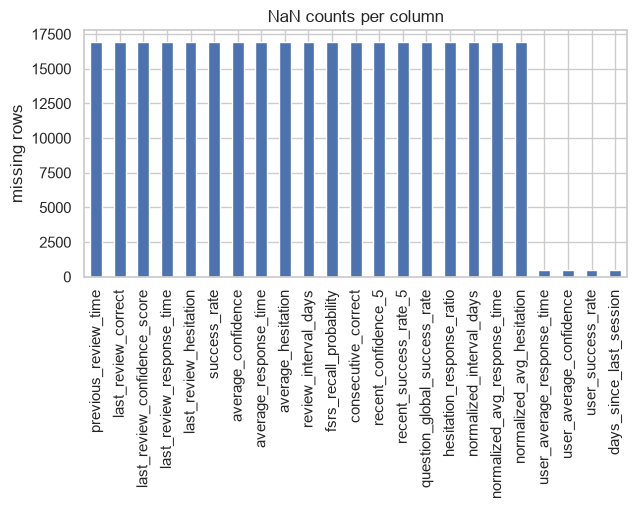

In [3]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.2))
na.plot.bar(ax=ax)
ax.set_title("NaN counts per column")
ax.set_ylabel("missing rows")

first_reviews = int((df["total_revisions"] == 0).sum())
print(f"rows with total_revisions == 0 : {first_reviews}")
print(f"rows with NaN success_rate     : {int(df['success_rate'].isna().sum())}")
print("-> all NaNs belong to first-ever reviews of a user-question pair")

**Observation:** every missing value is a *cold-start* artifact: 6,453
user-question pairs contribute exactly one first review each, and
`days_since_last_session` is NaN once per user. Imputation therefore only
affects ~6% of rows and is handled inside the sklearn pipeline during
training (fit on train folds only).

## 3. Numerical feature distributions

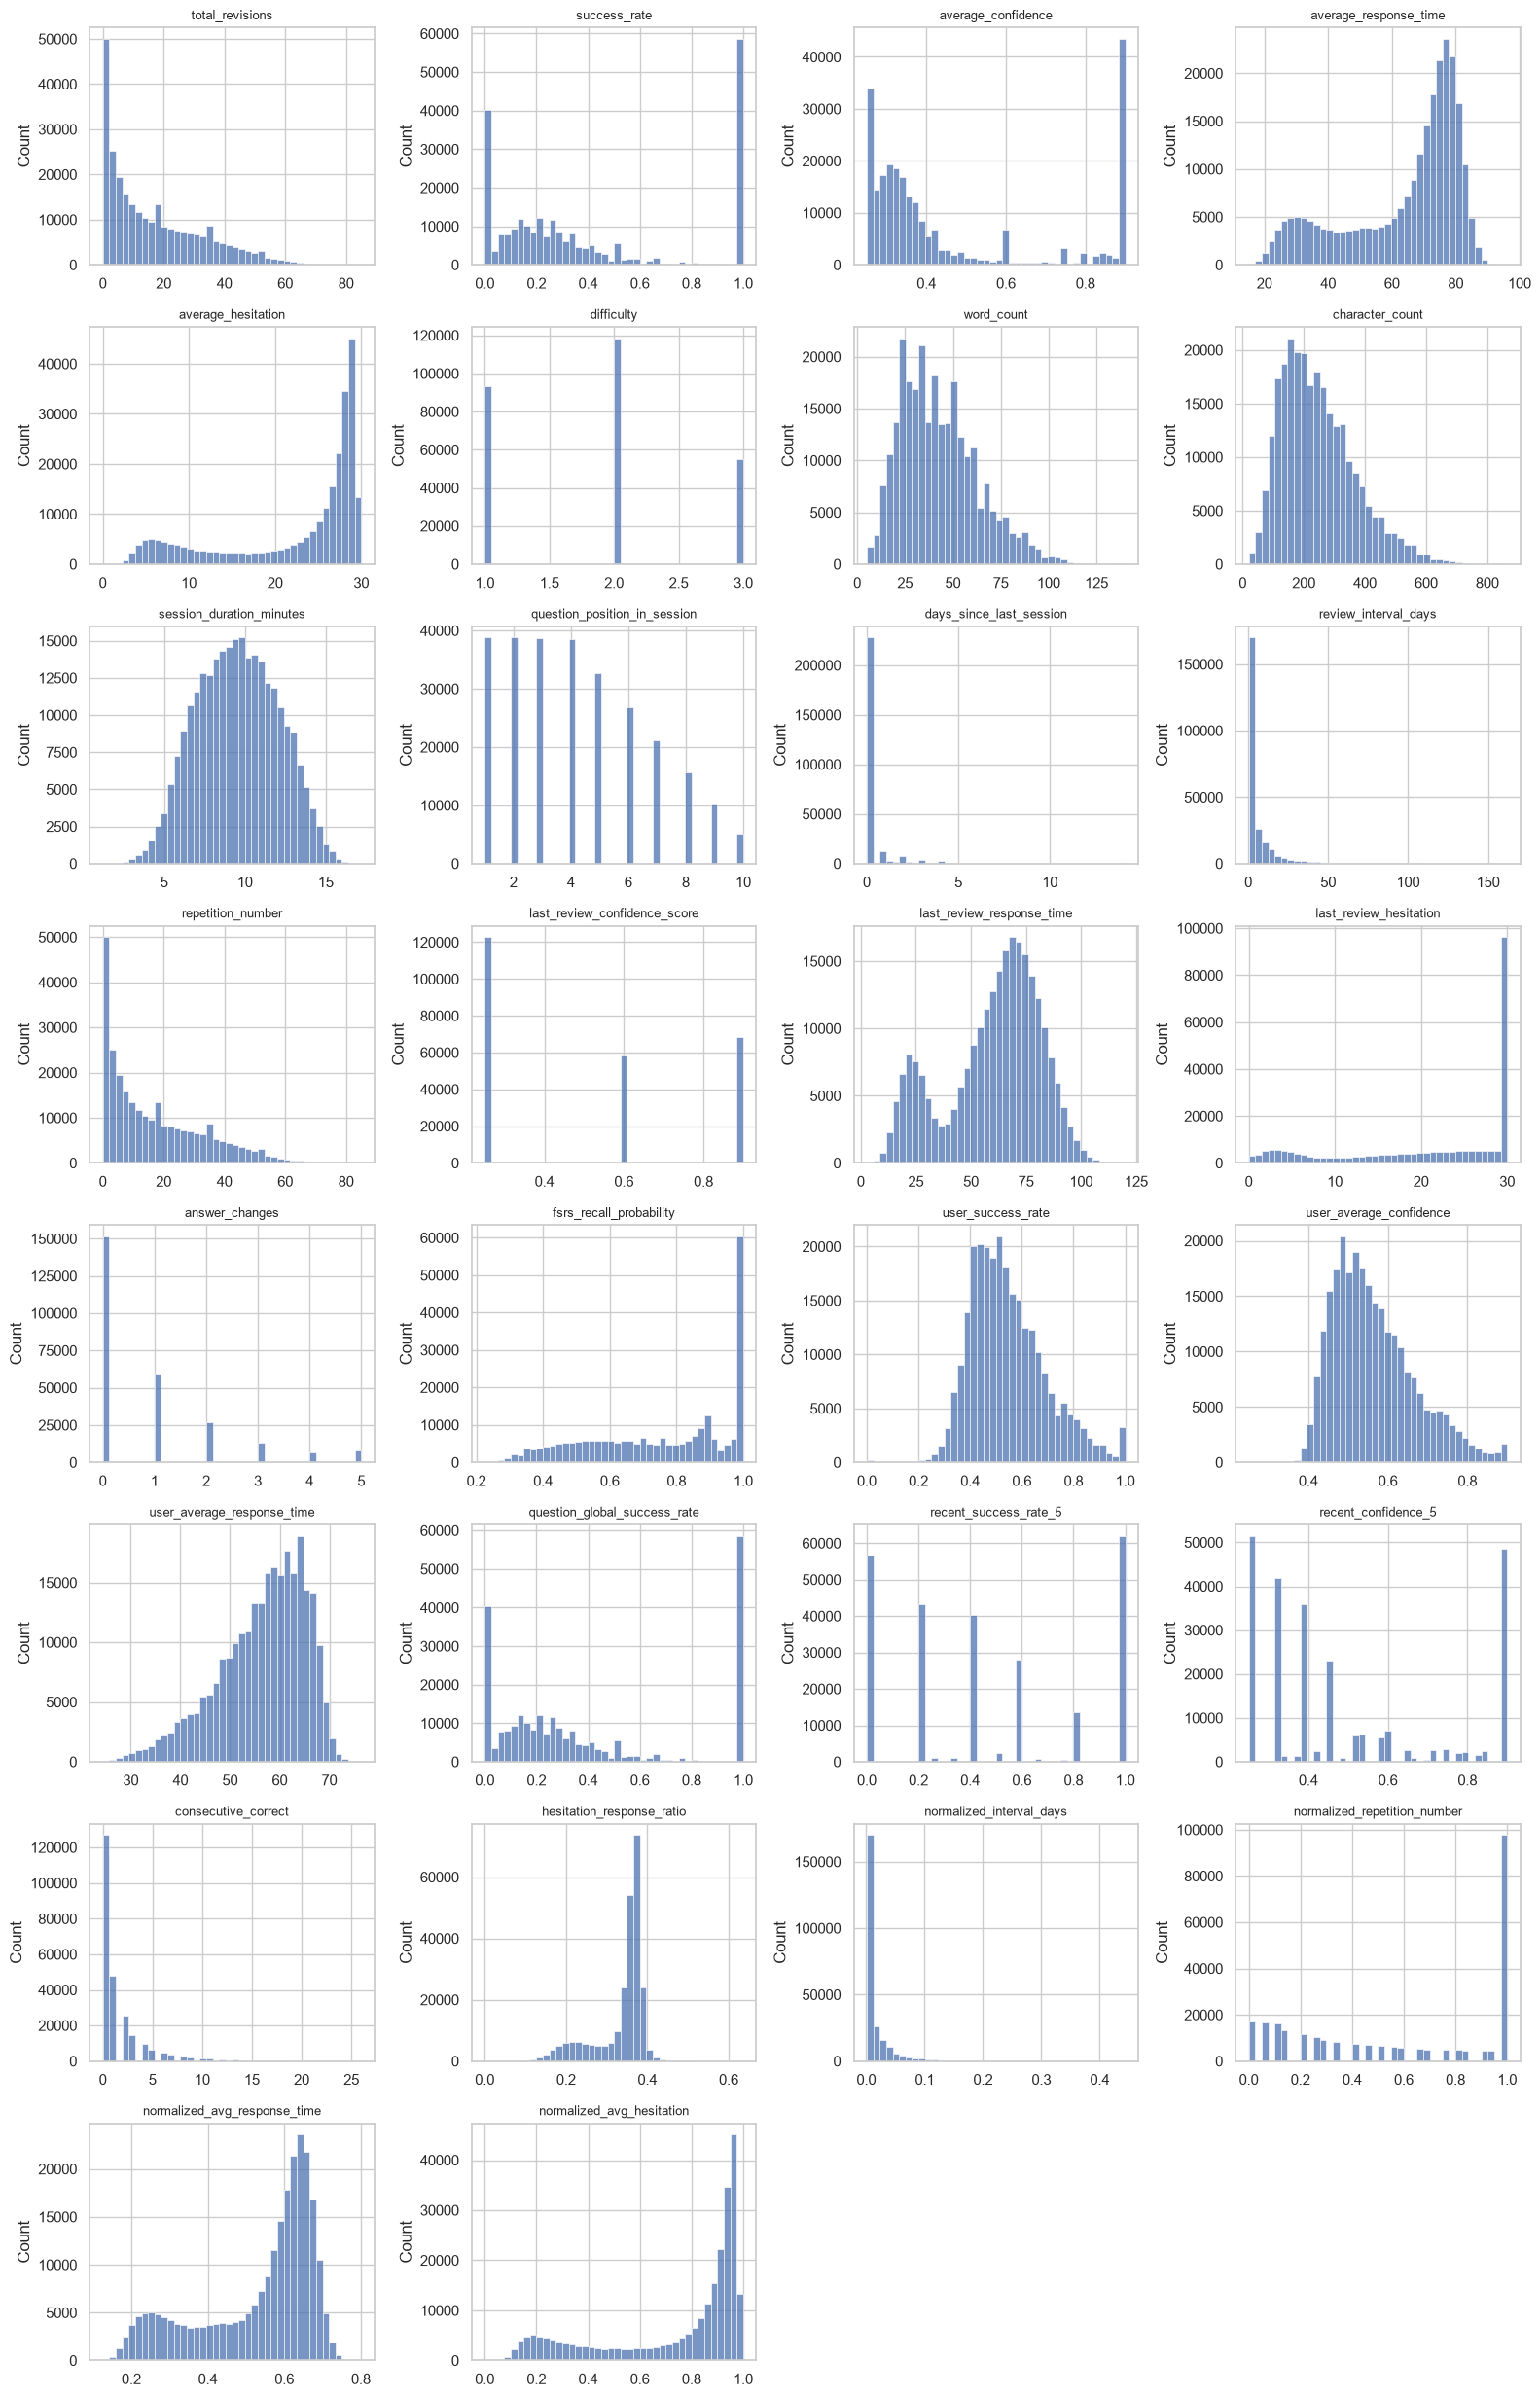

In [4]:
num_features = [c for c in NUMERICAL_FEATURES if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(num_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.1 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    sns.histplot(df[col].dropna(), bins=40, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for ax in axes[len(num_features):]:
    ax.axis("off")

plt.tight_layout()

**Observations**
- `response_time_seconds` / `hesitation_seconds`: strongly right-skewed —
  most recalls are fast; slow answers form a long tail.
- `review_interval_days`: decays quickly (FSRS short early intervals),
  with a long tail out past 100 days.
- `success_rate`, `average_confidence`, `average_*`: mass concentrated at
  high values plus a spike near fill defaults for early reviews.
- `difficulty` is discrete {1, 2, 3}; word/character counts are roughly normal.

## 4. Categorical features

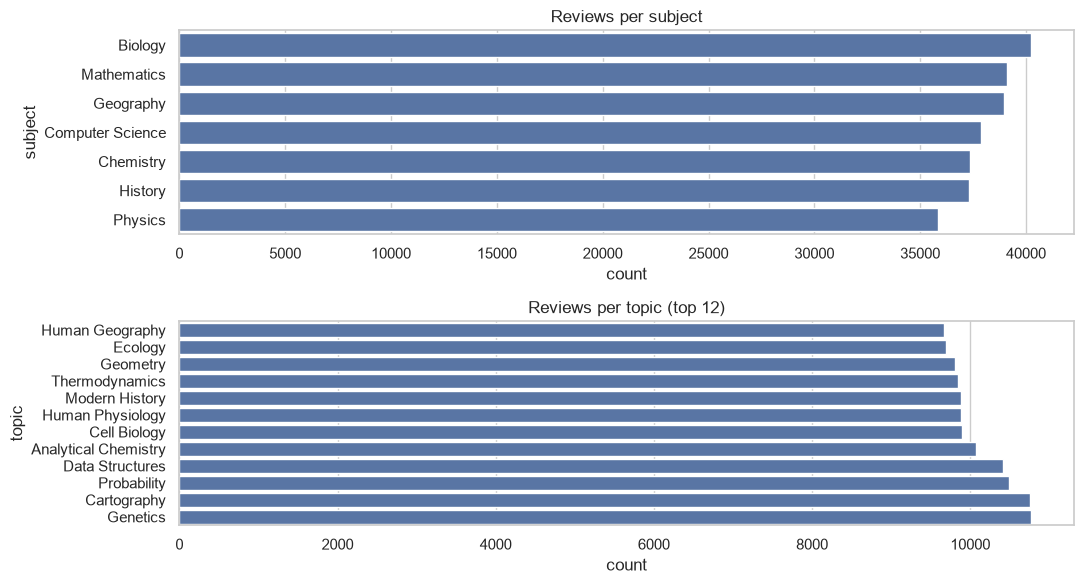

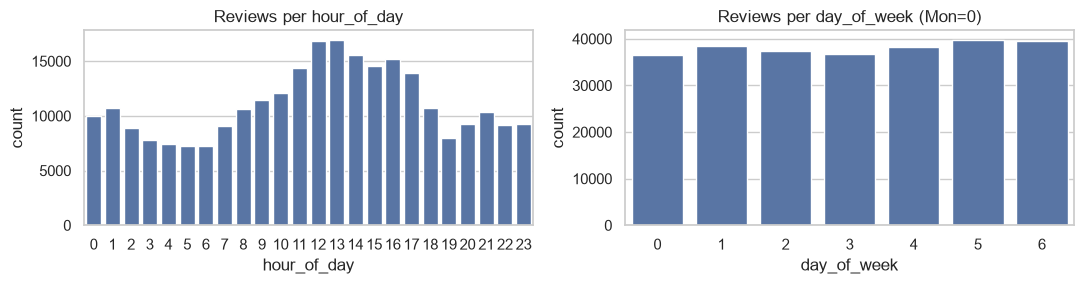

In [5]:
cat_cols = ["subject", "topic"]

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

order = df["subject"].value_counts().index
sns.countplot(data=df, y="subject", order=order, ax=axes[0])
axes[0].set_title("Reviews per subject")

top_topics = df["topic"].value_counts().head(12).index[::-1]
sns.countplot(data=df, y="topic", order=top_topics, ax=axes[1])
axes[1].set_title("Reviews per topic (top 12)")

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.countplot(data=df, x="hour_of_day", ax=axes[0])
axes[0].set_title("Reviews per hour_of_day")
sns.countplot(data=df, x="day_of_week", ax=axes[1])
axes[1].set_title("Reviews per day_of_week (Mon=0)")
plt.tight_layout()

**Observation:** subjects/topics are fairly uniform by construction.
`hour_of_day` clusters in evening hours and weekends differ from weekdays —
the timezone-aware session planner produces plausible circadian patterns.

## 5. Feature distributions split by target class

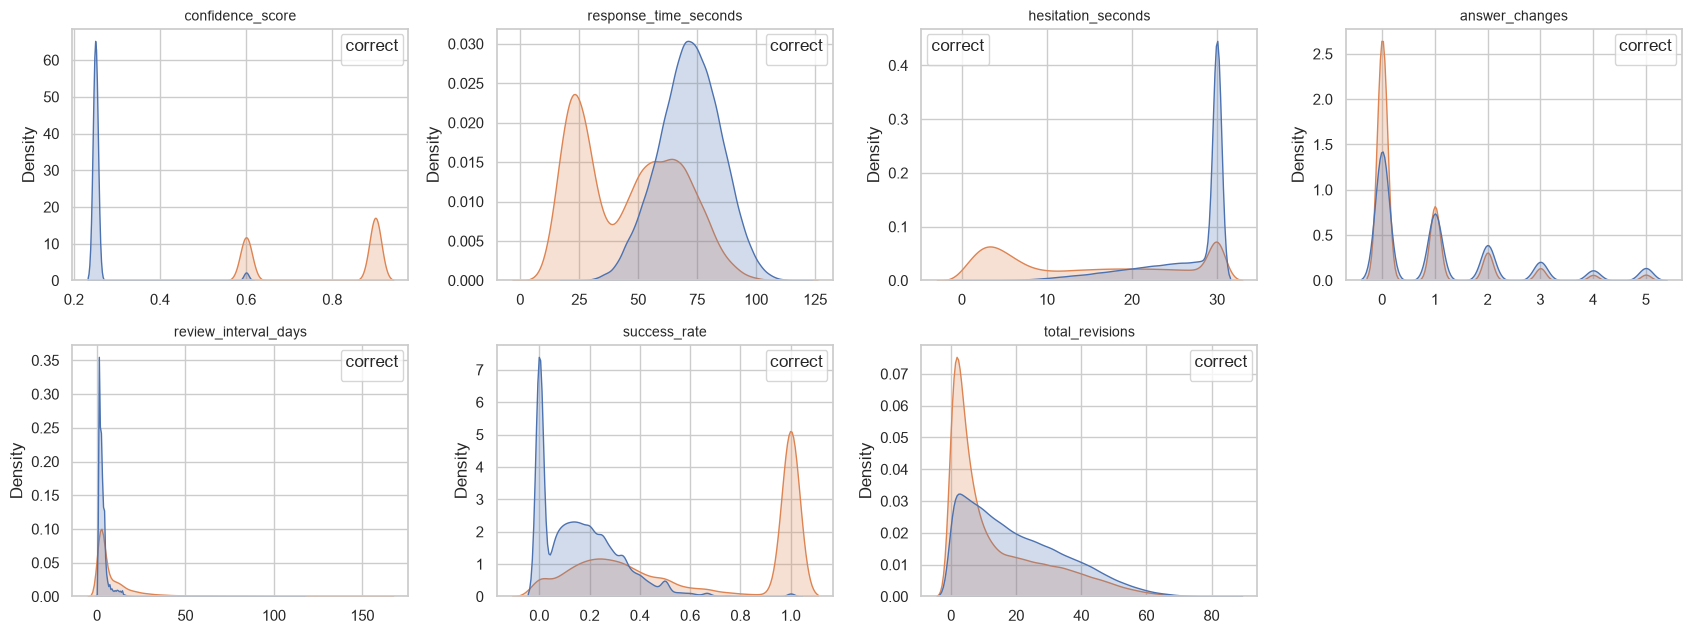

In [6]:
key_features = [
    "confidence_score",
    "response_time_seconds",
    "hesitation_seconds",
    "answer_changes",
    "review_interval_days",
    "success_rate",
    "total_revisions",
]

fig, axes = plt.subplots(2, 4, figsize=(17, 6.5))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.kdeplot(
        data=df, x=col, hue=TARGET, common_norm=False,
        fill=True, alpha=0.25, ax=ax,
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.legend(title="correct", loc="best", fontsize=8)

axes[-1].axis("off")

plt.tight_layout()

**Observation:** correctness separates clearly on behavioral features:
correct reviews show higher confidence scores, faster response times, less
hesitation and fewer answer changes. Interval separation is weaker but
present (forgotten material tends to have longer gaps). This confirms the
simulator injects learnable signal that FSRS alone does not use.

## 6. Correlation analysis

Text(0.5, 1.0, 'Pearson correlation matrix (numerical features + target)')

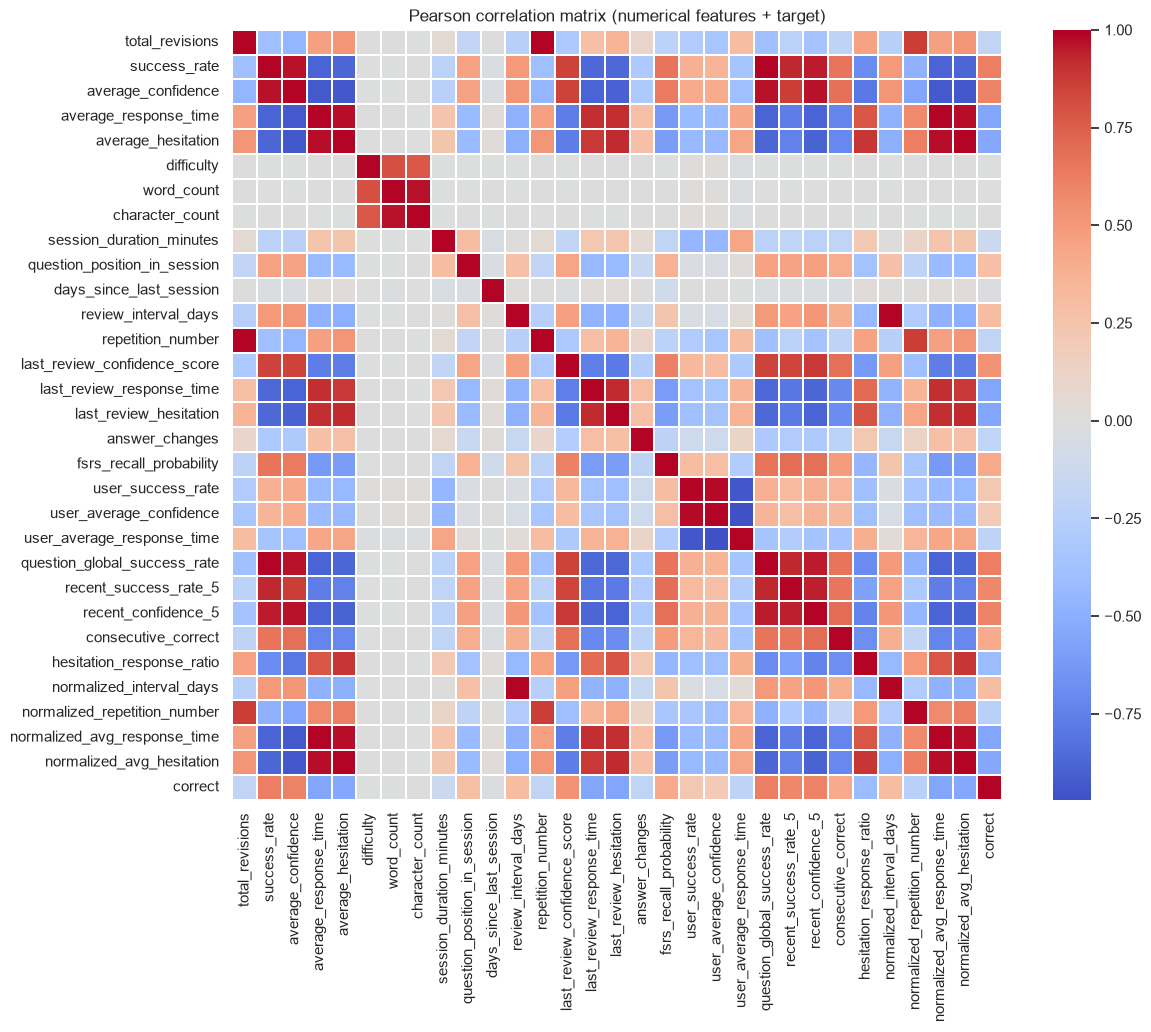

In [7]:
corr_cols = [c for c in NUMERICAL_FEATURES if c in df.columns] + [TARGET]
corr_df = df[corr_cols].copy()
corr_df[TARGET] = corr_df[TARGET].astype(int)

corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False,
            square=True, linewidths=0.3, ax=ax)
ax.set_title("Pearson correlation matrix (numerical features + target)")

Top multicollinear pairs:
success_rate           question_global_success_rate    1.000
review_interval_days   normalized_interval_days        1.000
average_hesitation     normalized_avg_hesitation       1.000
total_revisions        repetition_number               1.000
average_response_time  normalized_avg_response_time    1.000
user_success_rate      user_average_confidence         0.979
average_response_time  normalized_avg_hesitation       0.974
average_hesitation     normalized_avg_response_time    0.974


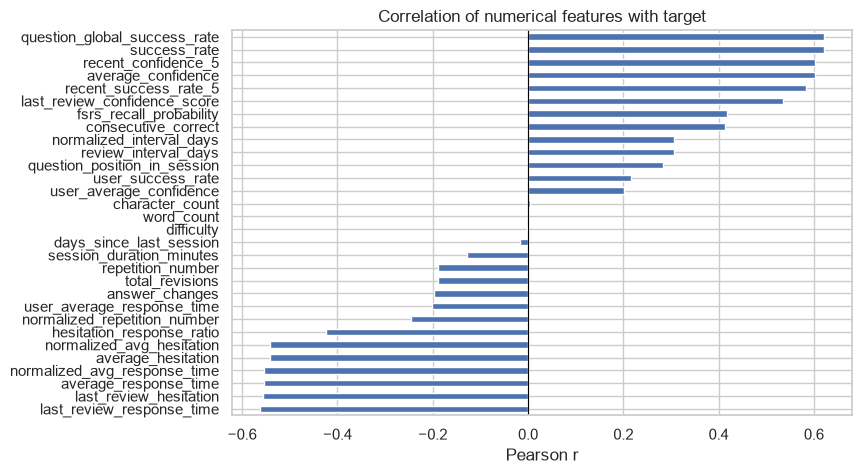

In [8]:
target_corr = corr[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
target_corr.plot.barh(ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of numerical features with target")
ax.set_xlabel("Pearson r")

pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("Top multicollinear pairs:")
print(pairs.head(8).round(3).to_string())

**Observations**
- Strongest positive signal: `confidence_score` / `average_confidence`,
  `success_rate`; strongest negative: `response_time_seconds`,
  `hesitation_seconds`.
- `word_count` ↔ `character_count` are almost collinear (expected) —
  tree models tolerate this; it would hurt unregularized linear models,
  which is why LogisticRegression gets scaling + L2 regularization.
- `average_*` features correlate with their raw counterparts (they are
  history summaries of the same quantity) but keep independent signal.

## 7. Empirical recall vs FSRS retrievability

reviews with an FSRS pre-review probability: 0.0%


,empirical,fsrs,n
interval_bucket,,,


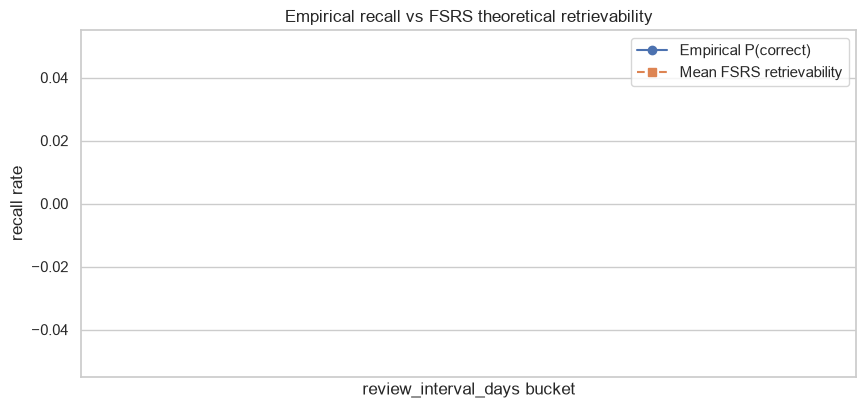

In [9]:
from src.database.connection import engine

schedules = pd.read_sql(
    "SELECT review_id, recall_probability FROM review_schedules",
    engine,
)

merged = df.merge(
    schedules,
    left_on="id",
    right_on="review_id",
    how="left",
)

covered = merged["recall_probability"].notna().mean()
print(f"reviews with an FSRS pre-review probability: {covered:.1%}")

bins = [0, 1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60, 90, 10_000]
labels = ["0-1","1-2","2-3","3-5","5-7","7-10","10-14","14-21",
          "21-30","30-45","45-60","60-90","90+"]

merged["interval_bucket"] = pd.cut(
    merged["review_interval_days"], bins=bins, labels=labels, include_lowest=True
)

bucket = merged.groupby("interval_bucket", observed=True).agg(
    empirical=("correct", "mean"),
    fsrs=("recall_probability", "mean"),
    n=("correct", "size"),
).dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(bucket))
ax.plot(x, bucket["empirical"], "o-", label="Empirical P(correct)")
ax.plot(x, bucket["fsrs"], "s--", label="Mean FSRS retrievability")
ax.set_xticks(x, bucket.index, rotation=45)
ax.set_xlabel("review_interval_days bucket")
ax.set_ylabel("recall rate")
ax.set_title("Empirical recall vs FSRS theoretical retrievability")
ax.legend()

bucket.round(3)

**Observation:** both curves decline monotonically with interval length —
the simulator's memory model and FSRS agree on the *shape* of forgetting.
Empirical recall sits above the FSRS curve at long intervals because the
behavioral model saturates at 0.05–0.95 while FSRS keeps decaying, and
because reviews only happen when cards come due (survivorship of well-known
cards at large intervals). The gap is exactly the residual an ML model can
exploit.

## 8. Pre-training feature importance

,mutual_info
question_global_success_rate,0.2378
success_rate,0.2376
average_confidence,0.2351
recent_confidence_5,0.2164
recent_success_rate_5,0.2105
fsrs_recall_probability,0.1907
last_review_response_time,0.1905
normalized_avg_response_time,0.1883


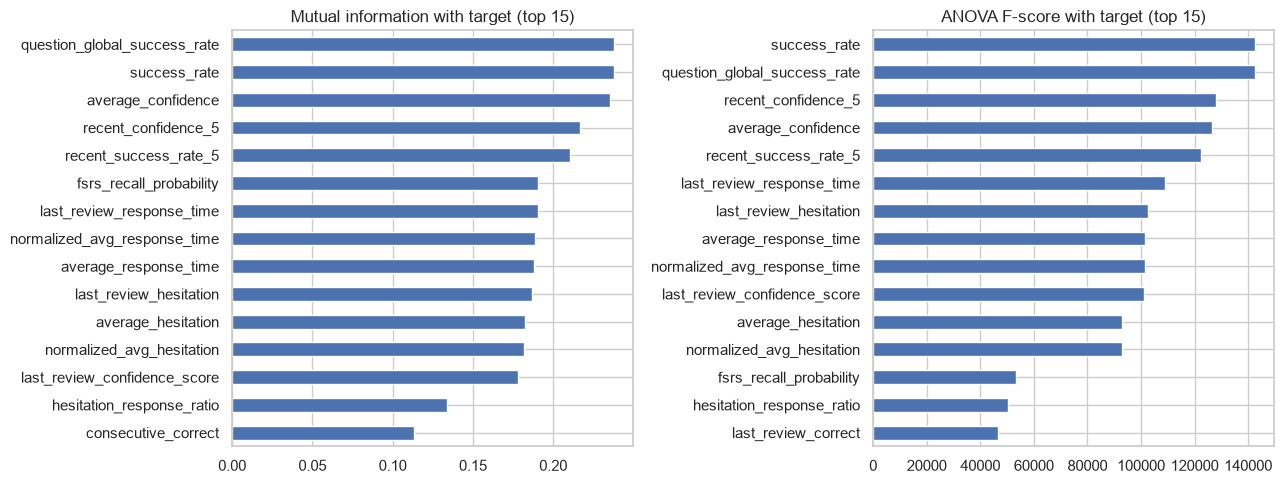

In [10]:
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

X_num = df[[c for c in NUMERICAL_FEATURES if c in df.columns]].copy()
X_bool = df[[c for c in BOOLEAN_FEATURES if c in df.columns]].copy()

for col in BOOLEAN_FEATURES:
    X_bool[col] = X_bool[col].fillna(False).astype(int)

cats = [c for c in CATEGORICAL_FEATURES if c in ("subject", "topic")]
X_cat_raw = df[cats].fillna("missing").astype(str)
X_cat = pd.DataFrame(
    OrdinalEncoder().fit_transform(X_cat_raw),
    columns=cats, index=df.index,
)

temporal_cats = [c for c in CATEGORICAL_FEATURES if c in ("hour_of_day", "day_of_week")]

X = pd.concat(
    [
        pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num),
                     columns=X_num.columns, index=df.index),
        X_bool,
        X_cat,
        df[temporal_cats],
    ],
    axis=1,
)
y = df[TARGET].astype(int)

mi = pd.Series(
    mutual_info_classif(X, y, random_state=42), index=X.columns
).sort_values(ascending=False)

f_scores = pd.Series(f_classif(X, y)[0], index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mi.sort_values().tail(15).plot.barh(ax=axes[0])
axes[0].set_title("Mutual information with target (top 15)")
f_scores.sort_values().tail(15).plot.barh(ax=axes[1])
axes[1].set_title("ANOVA F-score with target (top 15)")
plt.tight_layout()

mi.head(8).round(4).to_frame("mutual_info")

## 9. Key questions answered

| Question | Answer |
|---|---|
| Does confidence dominate? | It is the top single feature, but response time/hesitation/success-rate add substantial signal — the ML model has room beyond a pure confidence rule. |
| Multicollinearity? | `word_count`↔`character_count` ≈ collinear; harmless for trees, handled by regularization for LR. |
| Temporal features meaningful? | Yes — hour/day show realistic study patterns; interval drives forgetting. |
| Baseline accuracy? | Majority class ≈ **53.4%**; any credible model must beat this clearly. |
| Do running averages converge or stay at fills? | They converge fast after the first few reviews; only the initial ~6% rely on imputed values. |
